# Coding Assignment 2: Exploratory Data Analysis on Diabetes Dataset

## Background
Diabetes is one of the most prevalent chronic diseases and creates significant burdens on healthcare systems. The **Diabetes 130-US hospitals dataset** contains over **100,000 records** of hospital admissions for diabetic patients across **130 U.S. hospitals (1999–2008)**. It includes more than **50 attributes**, covering demographics, admission details, diagnoses, lab results, medications, and hospital outcomes.  

Like many real-world healthcare datasets, it presents challenges such as missing values, categorical codes (ICD-9 diagnoses, drug prescriptions), imbalances in outcome variables (e.g., readmission), and inconsistent data formats. Conducting an in-depth **Exploratory Data Analysis (EDA)** will help uncover insights into patient demographics, treatment outcomes, and factors influencing readmission rates.  

---

## Objectives
The goal of this assignment is to conduct a comprehensive **qualitative and quantitative EDA** of the Diabetes dataset. You will:  

- **Understand** the dataset structure, including variables, data types, and overall composition.  
- **Detect and address** data quality issues, such as missing values, duplicates, and inconsistent categories.  
- **Conduct univariate, bivariate, and multivariate analysis** using both qualitative and quantitative EDA, supported by visualization techniques (bar charts, count plots, stacked charts, heatmaps) and statistical methods (descriptive statistics, distribution analysis, and exploration of variable relationships).  
- **Visualize** patterns and correlations to uncover key insights and trends.  

---

## Submission Instructions
- This is an **individual assignment** and carries **5% of the total marks** of this course. 
- You should not discuss your progress or solutions with anyone else.  
- Use this **template Jupyter Notebook and dataset** for your work.  

At the beginning of the notebook, clearly state:  
1. **Your Name and Roll Number**  
2. **Python environment details** (version, libraries used).  
3. Whether you are running locally or on **Google Colab** (*preferred, to ensure all students work in a consistent environment*).  

Additional guidelines:  
- Ensure that your notebook is **fully reproducible**: every cell must run sequentially without errors to regenerate the results.  
- Submit a **single completed notebook file (.ipynb)** before the deadline.  

---


## Dataset Source
- Source of Data : https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008
- It represents **hospital admissions of diabetic patients** across 130 U.S. hospitals from 1999 to 2008.
- Read the **Variables Table** in the link above, which provides details of individual variables such as type, role, and description.

##  Dataset Overview - "Diabetes_dataset.csv"
- **Number of records:** ~101,766 hospital admissions  
- **Number of features:** 53  
- **Unit of analysis:** Each row represents **one hospital admission** for a patient (a patient can have multiple admissions).  
- **Target variable (Goal):** Predict whether a patient is **readmitted within 30 days** of discharge.  

###  Key Features with Mappings
- **Admission Type**: `admission_type_id` → mapped to `admission_type_desc`  
- **Discharge Disposition**: `discharge_disposition_id` → mapped to `discharge_desc`  
- **Admission Source**: `admission_source_id` → mapped to `admission_source_desc`  

---

##  Important Notes
- **Missing values:** Several features contain missing values, often recorded as `"?"` (not as `NaN`).   
- **ID columns:** Both numeric IDs and their human-readable descriptions are included after merging. IDs may be useful for re-checking or remapping, while descriptions are helpful for analysis.  


**Note:** Do not just run plots — write down **interpretations** of your findings.  
The goal is to practice *thinking about the data*, not just generating charts.


# 📌 Preamble: Environment Details

Before starting the assignment, please fill in the following:

- **Name**: SWAPNIL TRIVEDI 
- **Roll Number**:  13-19-01-19-52-24-1-24723
- **Environment**: Local Machine 

Run the code cell below to print your Python and library versions.


In [13]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from ydata_profiling import ProfileReport

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)

%matplotlib inline

Python version: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
Pandas version: 2.3.2
NumPy version: 1.26.4
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


## Load and Inspect the dataset structure 

In [14]:
input_dataset_path = './Diabetes_dataset.csv'
data=pd.read_csv(input_dataset_path)
print("Dataset loaded successfully with shape:", data.shape)
# print("First few rows of the dataset:")
# print(data.head(5))

Dataset loaded successfully with shape: (101766, 53)


In [15]:
## data exploration types of data onjects and their info
print("\nDataset Information:")
data.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-

In [16]:
# statistical summary of the dataset
print("\nStatistical Summary of the Dataset:")
data.describe()


Statistical Summary of the Dataset:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [17]:
# Summarize the dataset
summary = {
    "Number of rows": len(data),
    "Number of columns": len(data.columns),
    "Column names": data.columns.tolist(),
    "Data types": data.dtypes.to_dict(),
    "Missing values per column": data.isnull().sum().to_dict(),
    "Unique values per column": data.nunique().to_dict(),
}
print("\nDataset Summary:")
print("\t --> Number of rows:", summary["Number of rows"])
print("\t --> Number of columns:", summary["Number of columns"])
print("Column names:", summary["Column names"])
print("Data types:")
## group data types
data_types = {}
for col, dtype in summary["Data types"].items():
    dtype_str = str(dtype)
    if dtype_str not in data_types:
        data_types[dtype_str] = []
    data_types[dtype_str].append(col)
for dtype, cols in data_types.items():
    print(f"\t --> {dtype}: {cols}")
print("Missing values per column")
for col, missing in summary["Missing values per column"].items():
    if missing > 0:
        print(f"\t --> {col}: {missing}")


Dataset Summary:
	 --> Number of rows: 101766
	 --> Number of columns: 53
Column names: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type_desc', 'discharge_desc', 'admission_source_desc']
Data types:
	 --> int64: ['

### A lot of categorical variables are present which needs to be encoded and explored, some of them needs to be converted into numerical variables itself, example age is object but should be converted into numerical variable.


#### Using Ydata for reporting

In [18]:
profile = ProfileReport(data, title="Diabetes Dataset Raw- EDA Report")
profile.to_file("diabetes_data_eda_raw_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 53/53 [00:05<00:00, 10.26it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Data Pre-processing (cleaning, transformation, handling missing values, etc.)

In [19]:
## drop duplicates if any
initial_shape = data.shape
data.drop_duplicates(inplace=True)
if data.shape != initial_shape:
    print(f"Dropped {initial_shape[0] - data.shape[0]} duplicate rows. New shape: {data.shape}")
else:
    print("No duplicate rows found.")

No duplicate rows found.


##### Per column cleaning and transformation

In [20]:
### list of numerical columns
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumerical columns:", numerical_cols)
print("Statistical summary of numerical columns:")
print(data[numerical_cols].info())


Numerical columns: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Statistical summary of numerical columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   admission_type_id         101766 non-null  int64
 3   discharge_disposition_id  101766 non-null  int64
 4   admission_source_id       101766 non-null  int64
 5   time_in_hospital          101766 non-null  int64
 6   num_lab_procedures        101766 non-null  int64
 7   num_procedures            101766 non-null  int64
 8   num_medications   

# Analysis of Numerical columns

- Total numerical columns: 13, including identifiers, admission details, and clinical measures.
- No missing values: All numerical columns are complete for all 101,766 records.
- Column types: All are integers (int64), suitable for counts and coded categories.
- Identifiers: encounter_id and patient_nbr are unique IDs, not useful for statistical analysis but important for tracking.
- Admission and discharge codes: Columns like admission_type_id, discharge_disposition_id, and admission_source_id are categorical codes and should be mapped to their descriptions for interpretation.
- Clinical measures: Columns such as time_in_hospital, num_lab_procedures, num_procedures, num_medications, and various number_* columns provide quantitative information about patient care and hospital resource use.
- Data quality: No duplicates or missing data in these columns, making them reliable for further analysis.

In [21]:
# statistical summary of numerical columns
print("\nStatistical Summary of Numerical Columns:")
print(data[numerical_cols].describe())


Statistical Summary of Numerical Columns:
       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%     

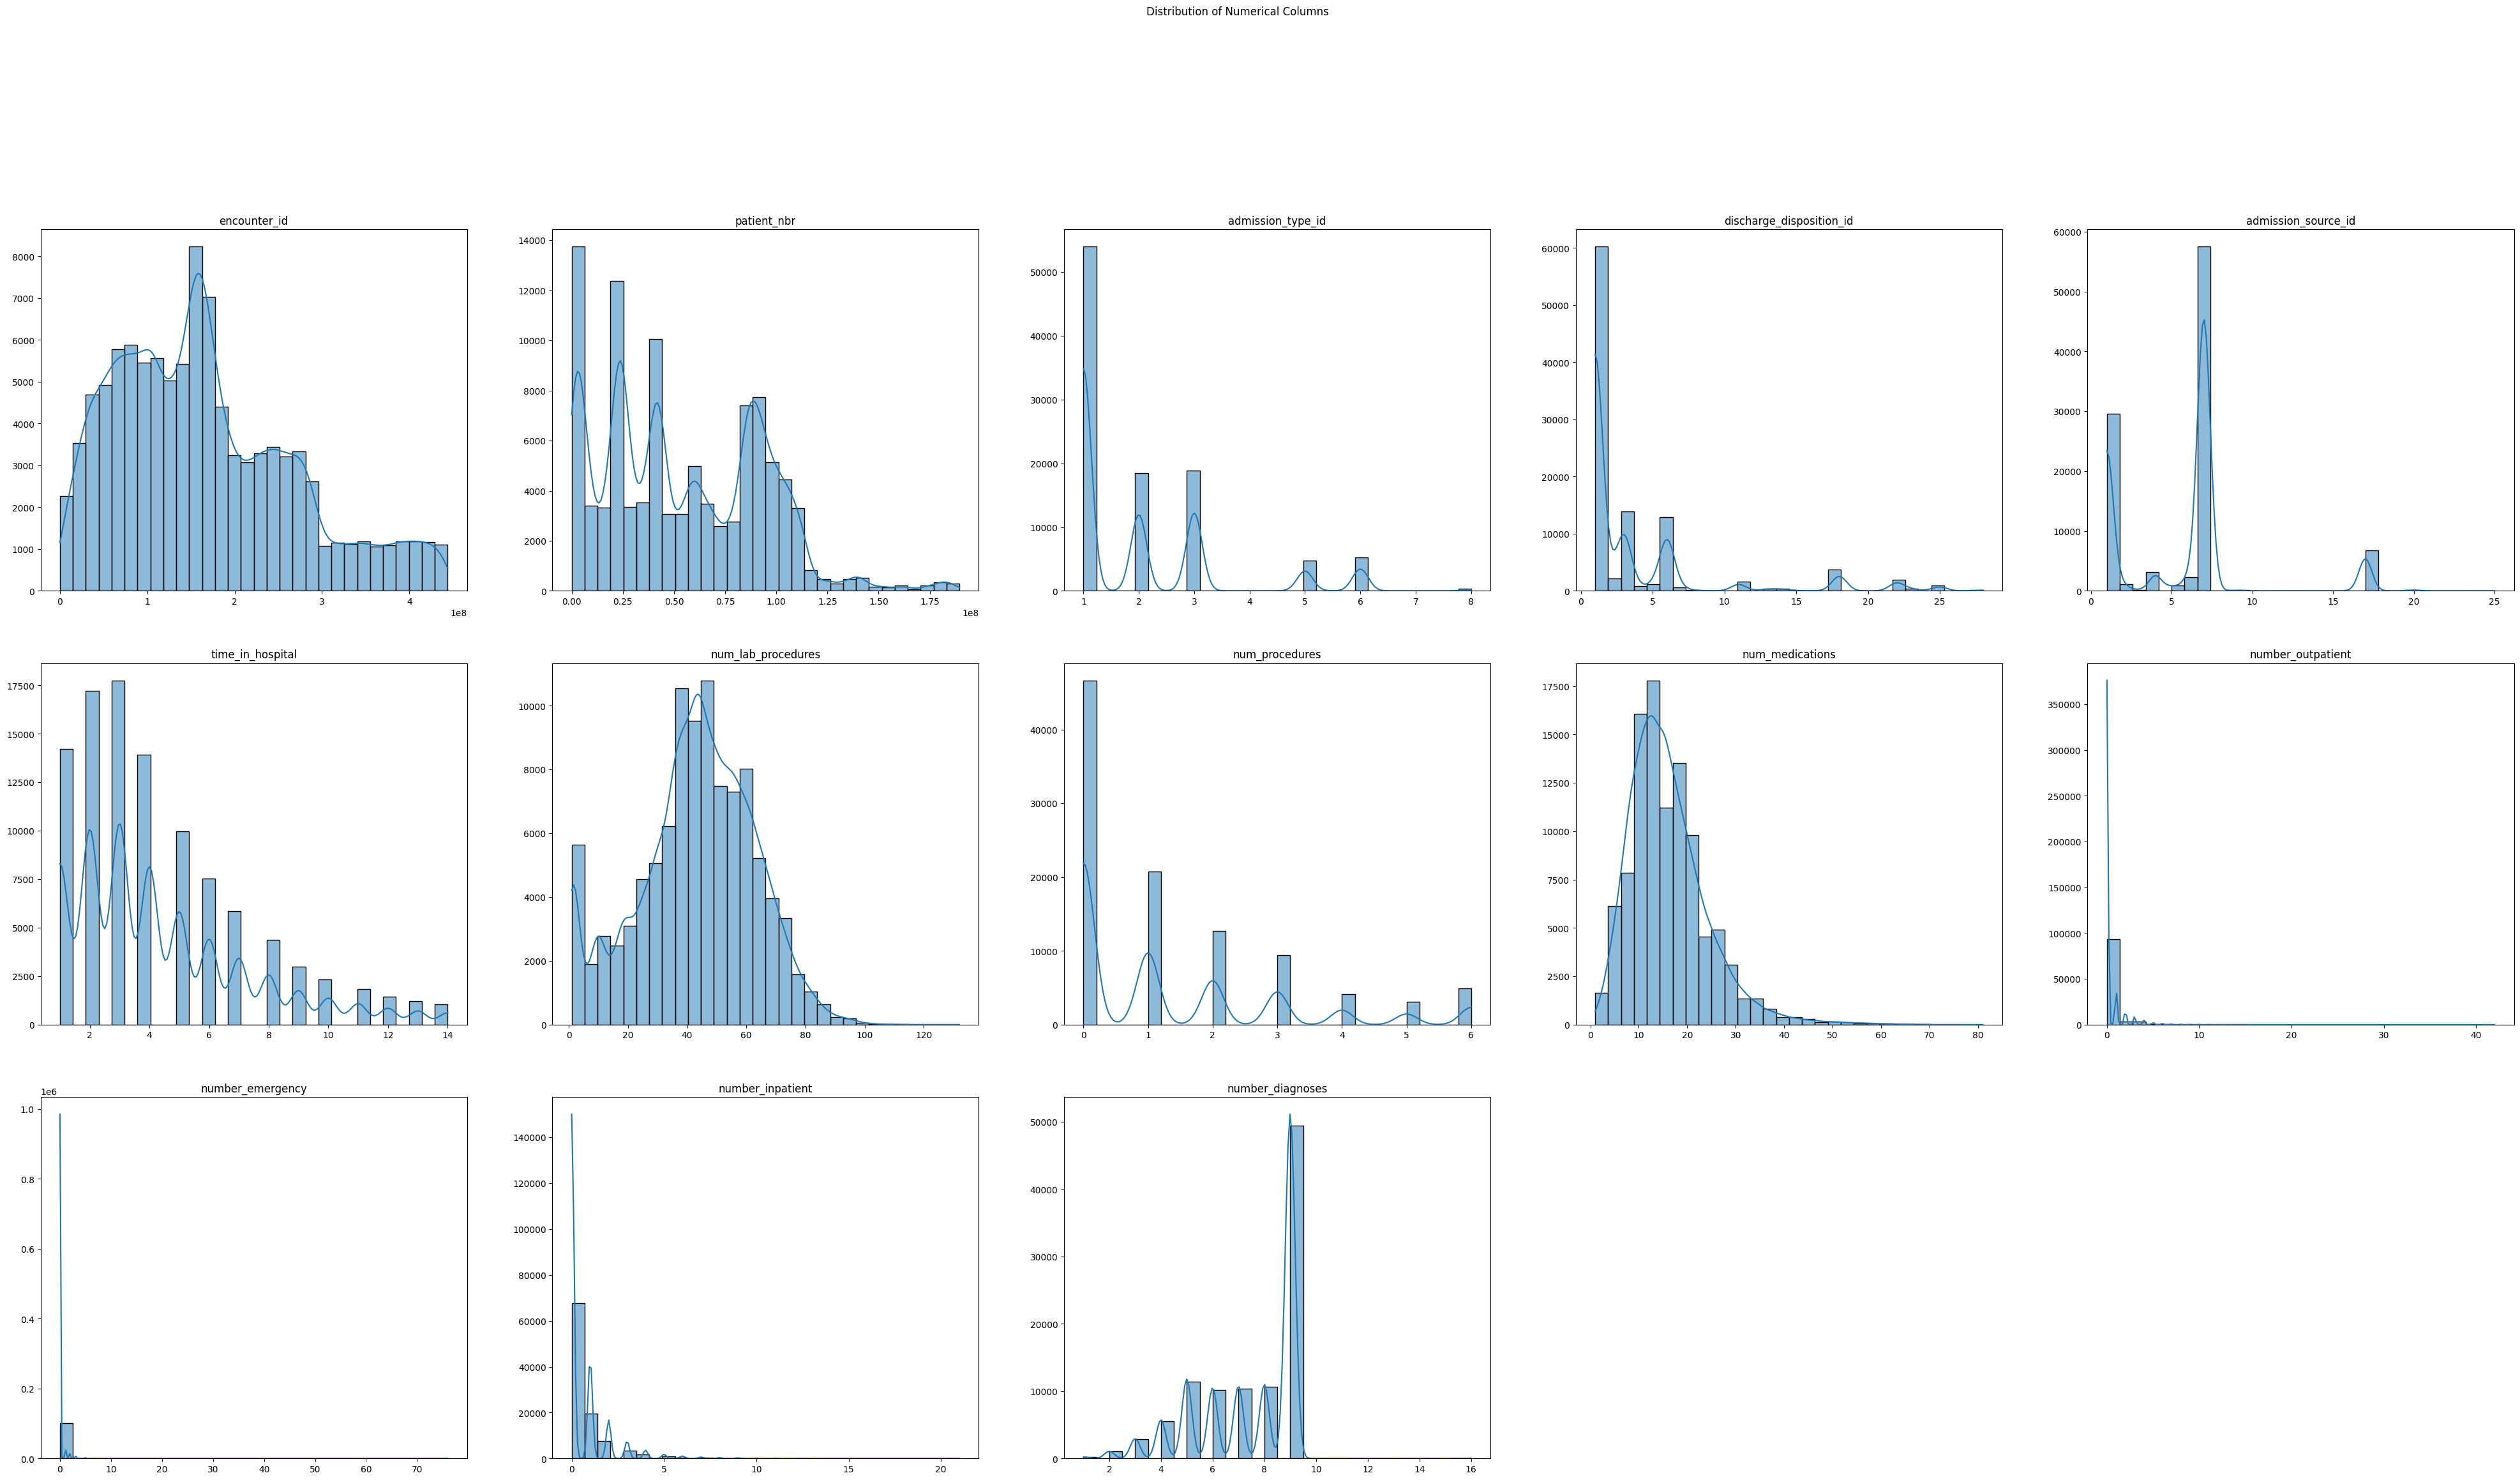

In [22]:
plt.figure(figsize=(50,25))
plt.tight_layout()
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 5, i + 1)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')
plt.suptitle('Distribution of Numerical Columns', y=1.02)
plt.show()

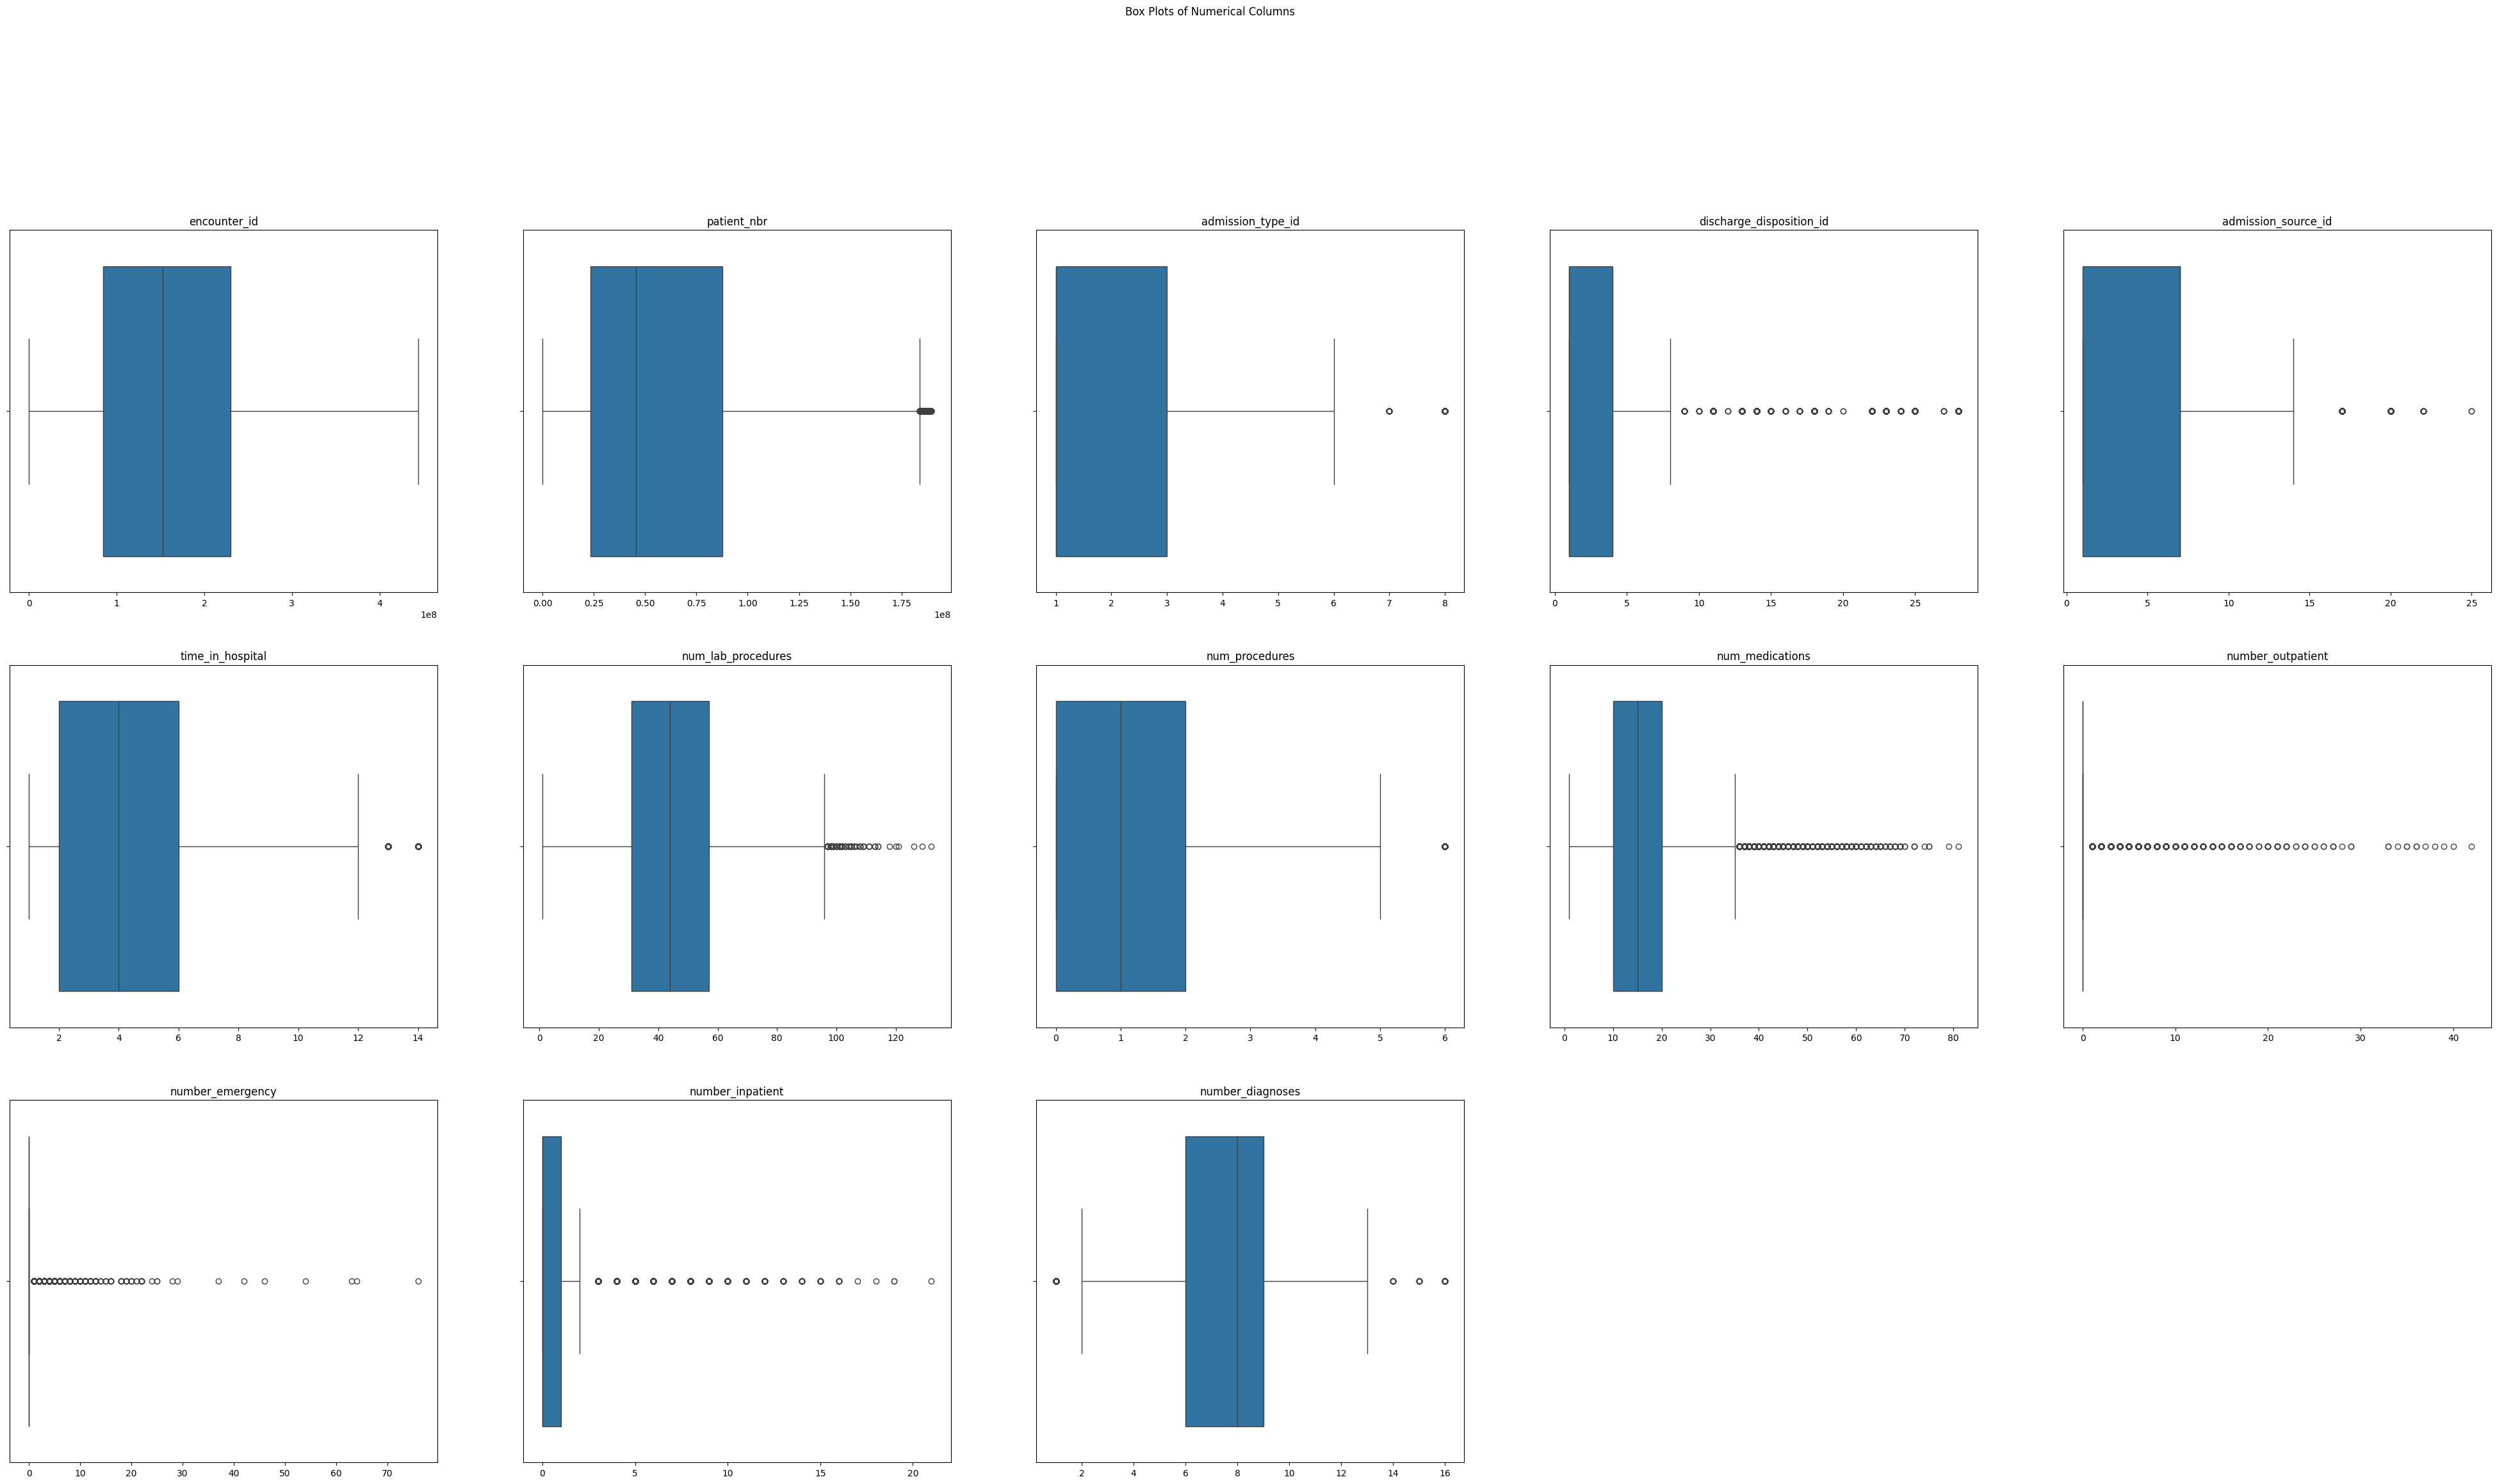

In [23]:
## box plot for outliers detection
plt.figure(figsize=(50,25))
plt.tight_layout()
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 5, i + 1)
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')
plt.suptitle('Box Plots of Numerical Columns', y=1.02)
plt.show()
# Analysis of Numerical columns

#### Outliers and distribution of numerical columns are skewed, need to be treated accordingly. and shows multiple outliers. But most of them columns are identifiers so not much important for analysis.

Can drop the identifiers columns as they are not useful for analysis.Below are the numerical columns present in the dataset and their descriptions as understood from the report from ydata profiling.
### list of numerical columns
- encounter_id : Unique identifier for each hospital encounter.
- patient_nbr : Unique identifier for each patient.
- admission_type_id : Categorical code for type of admission.
- discharge_disposition_id : Categorical code for discharge status.
- adminission_source_id : Categorical code for admission source.
- time_in_hospital : Number of days the patient was hospitalized.
- num_lab_procedures : Number of lab tests performed during the stay.
- num_procedures : Number of procedures performed during the stay.
- num_medications : Number of distinct medications prescribed during the stay.
- number_outpatient : Number of outpatient visits in the year prior to admission.
- number_emergency : Number of emergency visits in the year prior to admission.
- number_inpatient : Number of inpatient visits in the year prior to admission.
- number_diagnoses : Number of diagnoses recorded during the stay.          

All these columns are of integer type (int64) and have no missing values. The identifiers (encounter_id, patient_nbr) are unique for each record. The other numerical columns provide quantitative information about the patient's hospital stay, treatments, and prior healthcare utilization. There are no duplicates or missing data in these numerical columns, making them reliable for further analysis.


4   admission_source_id       101766 non-null  int64
 5   time_in_hospital          101766 non-null  int64
 6   num_lab_procedures        101766 non-null  int64
 7   num_procedures            101766 non-null  int64
 8   num_medications           101766 non-null  int64
 9   number_outpatient         101766 non-null  int64
 10  number_emergency          101766 non-null  int64
 11  number_inpatient          101766 non-null  int64
 12  number_diagnoses 

In [24]:
data.time_in_hospital.head()

0    1
1    3
2    2
3    2
4    1
Name: time_in_hospital, dtype: int64

## Do attribute to id mapping for categorical columns
- **Admission Type**: `admission_type_id` → mapped to `admission_type_desc`  
- **Discharge Disposition**: `discharge_disposition_id` → mapped to `discharge_desc`  
- **Admission Source**: `admission_source_id` → mapped to `admission_source_desc`  

In [27]:
# map admission_type_id to admission_type_desc
admission_type_id = data.admission_type_id.unique()
admission_type_desc = data.admission_type_desc.unique()
admission_type_mapping = dict(zip(admission_type_id, admission_type_desc))
data['admission_type'] = data['admission_type_id'].map(admission_type_mapping)
data.drop(columns=['admission_type_id', 'admission_type_desc'], inplace=True)

In [28]:
# map discharge_disposition_id to discharge_desc
discharge_disposition_id = data.discharge_disposition_id.unique()
discharge_desc = data.discharge_desc.unique()
discharge_mapping = dict(zip(discharge_disposition_id, discharge_desc))
data['discharge_disposition'] = data['discharge_disposition_id'].map(discharge_mapping)
data.drop(columns=['discharge_disposition_id', 'discharge_desc'], inplace=True) 


In [29]:
# map admission_source_id to admission_source_desc
admission_source_id = data.admission_source_id.unique()
admission_source_desc = data.admission_source_desc.unique()
admission_source_mapping = dict(zip(admission_source_id, admission_source_desc))
data['admission_source'] = data['admission_source_id'].map(admission_source_mapping)
data.drop(columns=['admission_source_id', 'admission_source_desc'], inplace=True)

In [30]:
# check for NaN or ? missing values in categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns:", categorical_cols)
for col in categorical_cols:
    num_missing = data[col].isnull().sum() + (data[col] == '?').sum()
    if num_missing > 0:
        print(f"\t --> {col}: {num_missing} missing values")


Categorical columns: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type', 'discharge_disposition', 'admission_source']
	 --> race: 2273 missing values
	 --> weight: 98569 missing values
	 --> payer_code: 40256 missing values
	 --> medical_specialty: 49949 missing values
	 --> diag_1: 21 missing values
	 --> diag_2: 358 missing values
	 --> diag_3: 1423 missing values
	 --> max_glu_serum: 96420 missing values
	 --> A1Cresult: 84748 missing values
	 --> admission_type: 5291 mi

## Univariate Analysis

## Bivariate Analysis

## Multivariate Analysis

## Summarize insights

##### Raw Dataset Statistics
- Number of variables           :	53
- Number of observations        :	101,766
- Missing cells	                :  196,931
- Missing cells (%)	            :  3.7%
- Duplicate rows	            :  0
- Duplicate rows (%)	        :  0.0%
- Total size in memory	        :  41.2 MiB
- Average record size in memory	: 424.0 B
##### Variable types
- Numeric	    : 13
- Categorical	: 33
- Text	        : 4
- Boolean	    : 3